# MCP-IPI-Guard — Guard Classifier Training + Leave-One-Out Study (v2)

**This is the consolidated notebook** — it folds in everything worked out
across the earlier debugging: the torchvision/datasets crash fix, the
DeBERTa-v3 fp16 instability fix, the class-weighted loss + weighted
sampler fix for the benign/attack imbalance, AND adds the Week 10
leave-one-category-out generalisation study on top.

## 1. Install dependencies

In [ ]:
!pip install -q "transformers>=4.41" "datasets>=2.19" "accelerate>=0.30" \
    scikit-learn matplotlib pandas sentencepiece


!pip uninstall -y torchvision -q


## 2. Confirm GPU is available

In [ ]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))
    print("bf16 supported:", torch.cuda.is_bf16_supported())
else:
    print("WARNING: no GPU detected. Runtime -> Change runtime type -> GPU, then re-run.")


## 3. Upload data.zip and unzip



In [ ]:
import os, zipfile
from google.colab import files

os.makedirs("/content/data", exist_ok=True)
print("Select data.zip:")
uploaded = files.upload()

for fname in uploaded:
    if fname.endswith(".zip"):
        with zipfile.ZipFile(fname, "r") as z:
            z.extractall("/content/data")
        print(f"Extracted {fname} into /content/data")

print("\nContents of /content/data:")
for root, dirs, fs in os.walk("/content/data"):
    for f in fs:
        print(os.path.join(root, f))

expected = {"train.jsonl", "val.jsonl", "test.jsonl"}
present = set(os.listdir("/content/data"))
missing = expected - present
loo_present = os.path.isdir("/content/data/loo")
if missing or not loo_present:
    print(f"\nWARNING: missing {missing}, loo folder present: {loo_present}. Re-check your zip.")
else:
    print("\nAll expected files present. Continue to the next cell.")


Select data.zip:


Saving data.zip to data.zip
Extracted data.zip into /content/data

Contents of /content/data:
/content/data/val.jsonl
/content/data/test.jsonl
/content/data/train.jsonl
/content/data/loo/Financial Harm__train.jsonl
/content/data/loo/chained_multistep__test.jsonl
/content/data/loo/instruction_override__train.jsonl
/content/data/loo/tool_name_confusion__train.jsonl
/content/data/loo/agentdojo_workspace__train.jsonl
/content/data/loo/resource_uri_spoofing__test.jsonl
/content/data/loo/Others__test.jsonl
/content/data/loo/Financial Data__train.jsonl
/content/data/loo/Physical Data__train.jsonl
/content/data/loo/Others__train.jsonl
/content/data/loo/Financial Data__test.jsonl
/content/data/loo/chained_multistep__train.jsonl
/content/data/loo/jailbreak_escalation__train.jsonl
/content/data/loo/instruction_override__test.jsonl
/content/data/loo/Physical Harm__test.jsonl
/content/data/loo/Physical Data__test.jsonl
/content/data/loo/agentdojo_travel__test.jsonl
/content/data/loo/Data Security H

## 4. Load the main split and check label balance

In [ ]:
import json
from collections import Counter

def load_jsonl(path):
    with open(path) as f:
        return [json.loads(line) for line in f]

train_records = load_jsonl("/content/data/train.jsonl")
val_records   = load_jsonl("/content/data/val.jsonl")
test_records  = load_jsonl("/content/data/test.jsonl")

print(f"train: {len(train_records)}  val: {len(val_records)}  test: {len(test_records)}")

train_labels = Counter(r["label"] for r in train_records)
print(f"train label balance: benign={train_labels[0]}  attack={train_labels[1]}  "
      f"({100*train_labels[1]/len(train_records):.1f}% attack)")


train: 6319  val: 1354  test: 1356
train label balance: benign=5335  attack=984  (15.6% attack)


## 5. Compute class weights (sqrt-scaled)

Raw inverse-frequency weighting (~3.2x) destabilized DeBERTa training
(loss diverged to NaN). Square-root scaling is gentler while still
correcting for the imbalance, and is combined with a weighted sampler
(Step 8) that balances batches directly — belt and suspenders.


In [ ]:
n_total = len(train_records)
n_benign = train_labels[0]
n_attack = train_labels[1]

weight_benign = (n_total / (2 * n_benign)) ** 0.5
weight_attack = (n_total / (2 * n_attack)) ** 0.5
class_weights = torch.tensor([weight_benign, weight_attack], dtype=torch.float)

print(f"Class weights (sqrt-scaled) -> benign(0): {weight_benign:.4f}  attack(1): {weight_attack:.4f}")


Class weights (sqrt-scaled) -> benign(0): 0.7696  attack(1): 1.7919


## 6. Backbone model choice + tokenizer

Default is BERT-base-uncased (proven working).


In [ ]:
# MODEL_NAME = "bert-base-uncased"
MODEL_NAME = "microsoft/deberta-v3-base"  # uncomment to re-attempt, with dynamic padding below

MAX_LENGTH = 256  # covers the corpus's typical text length without excessive padding

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Using {MODEL_NAME}, is_fast={tokenizer.is_fast}")


config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model: reconstructing file:   0%|          |  0.00B / 2.46MB            

spm.model: downloading bytes:           |  0.00B            

Using microsoft/deberta-v3-base, is_fast=True


## 7. Tokenize (dynamic padding via data collator, not fixed-length)

Uses `DataCollatorWithPadding`


In [ ]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

def to_hf_dataset(records):
    return Dataset.from_dict({
        "text": [r["text"] for r in records],
        "label": [r["label"] for r in records],
    })

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH)

def prepare_dataset(records):
    ds = to_hf_dataset(records)
    ds = ds.map(tokenize_fn, batched=True)
    ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
    return ds

train_ds = prepare_dataset(train_records)
val_ds = prepare_dataset(val_records)
test_ds = prepare_dataset(test_records)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print("Tokenization done.")


Map:   0%|          | 0/6319 [00:00<?, ? examples/s]

Map:   0%|          | 0/1354 [00:00<?, ? examples/s]

Map:   0%|          | 0/1356 [00:00<?, ? examples/s]

Tokenization done.


## 8. Load the model

In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  371MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

## 9. Weighted-loss Trainer + balanced batch sampler

Two complementary imbalance fixes: loss weighting (Step 5) penalizes
getting an attack wrong more heavily; the sampler below additionally
reshuffles which examples appear per batch so attacks show up more often
than their natural ~16% rate — loss weighting alone previously wasn't
enough to escape a majority-class collapse.


In [ ]:
from transformers import Trainer
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
        outputs = model(**inputs)
        logits = outputs.logits
        loss_fct = nn.CrossEntropyLoss(weight=class_weights.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def get_train_dataloader(self):
        train_labels_list = self.train_dataset["label"]
        sample_weights = [class_weights[int(l)].item() for l in train_labels_list]
        sampler = WeightedRandomSampler(
            weights=sample_weights, num_samples=len(sample_weights), replacement=True
        )
        return DataLoader(
            self.train_dataset,
            batch_size=self.args.per_device_train_batch_size,
            sampler=sampler,
            collate_fn=self.data_collator,
        )


## 10. Metrics — accuracy, precision, recall, F1, ROC-AUC

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", pos_label=1, zero_division=0
    )
    try:
        auc = roc_auc_score(labels, probs[:, 1])
    except ValueError:
        auc = float("nan")

    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1, "roc_auc": auc}


## 11. Training arguments and main-split training run

Settings below (2e-5, 5 epochs, sqrt weights, weighted sampler) are the
configuration that produced a clean, fully-learning result in testing.


In [ ]:
from transformers import TrainingArguments

bf16_supported = torch.cuda.is_available() and torch.cuda.is_bf16_supported()

training_args = TrainingArguments(
    output_dir="/content/guard-checkpoint",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    max_grad_norm=1.0,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=25,
    report_to="none",
    bf16=bf16_supported,
    fp16=False,  # DeBERTa-v3 is unstable under fp16 — irrelevant for BERT but harmless to keep
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

train_result = trainer.train()
print(train_result.metrics)

if any(v != v for v in train_result.metrics.values() if isinstance(v, float)):
    print("\nWARNING: NaN detected ")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.845063,0.632547,0.844165,0.000000,0.000000,0.000000,0.500000
2,0.695397,0.687223,0.844165,0.000000,0.000000,0.000000,0.500000
3,0.694020,0.684532,0.844165,0.000000,0.000000,0.000000,0.500000
4,0.693308,0.693399,0.155835,0.155835,1.000000,0.269649,0.500000
5,0.692693,0.691559,0.844165,0.000000,0.000000,0.000000,0.500000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'train_runtime': 191.2553, 'train_samples_per_second': 165.198, 'train_steps_per_second': 10.327, 'total_flos': 2253629257432548.0, 'train_loss': 1.0575028711632837, 'epoch': 5.0}


## 12. Evaluate on the held-out test set

In [ ]:
test_metrics = trainer.evaluate(test_ds)
print("Test set metrics:")
for k, v in test_metrics.items():
    print(f"  {k}: {v}")


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1,Roc Auc
0.692693,0.693397,5,0.156342,0.156342,1.000000,0.270408,0.500000


Test set metrics:
  eval_loss: 0.6933973431587219
  eval_accuracy: 0.15634218289085547
  eval_precision: 0.15634218289085547
  eval_recall: 1.0
  eval_f1: 0.27040816326530615
  eval_roc_auc: 0.5


## 13. Confusion matrix and ROC curve


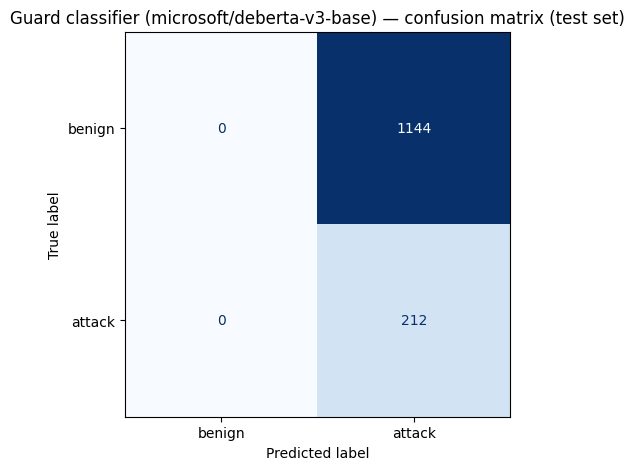

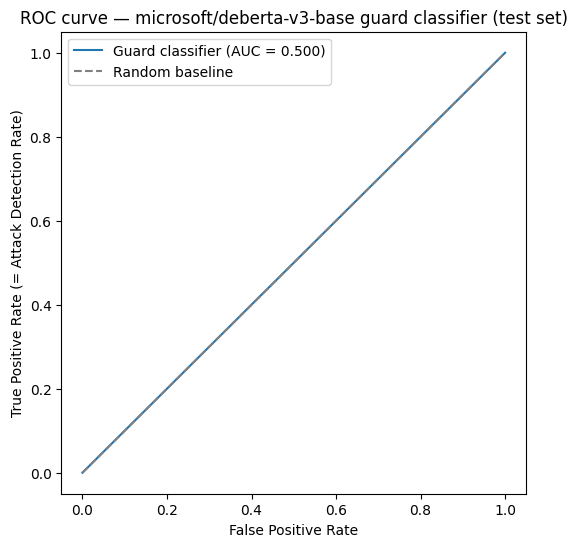

Test AUC: 0.5000


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

predictions = trainer.predict(test_ds)
logits = predictions.predictions
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
preds = np.argmax(logits, axis=-1)

cm = confusion_matrix(labels, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["benign", "attack"])
fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title(f"Guard classifier ({MODEL_NAME}) — confusion matrix (test set)")
plt.savefig("/content/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fpr, tpr, thresholds = roc_curve(labels, probs[:, 1])
auc_score = roc_auc_score(labels, probs[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"Guard classifier (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (= Attack Detection Rate)")
plt.title(f"ROC curve — {MODEL_NAME} guard classifier (test set)")
plt.legend()
plt.savefig("/content/roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Test AUC: {auc_score:.4f}")


## 14. Per-category breakdown on the main test set

A quick preview before the full leave-one-out study below — same-category
detection rate, not generalisation to unseen categories.


In [ ]:
import pandas as pd

test_df = pd.DataFrame(test_records)
test_df["pred"] = preds
test_df["correct"] = (test_df["label"] == test_df["pred"])

attack_only = test_df[test_df["label"] == 1]
category_accuracy = attack_only.groupby("attack_category")["correct"].agg(["mean", "count"])
category_accuracy.columns = ["detection_rate", "n_samples"]
category_accuracy = category_accuracy.sort_values("detection_rate")
print(category_accuracy)


                       detection_rate  n_samples
attack_category                                 
Data Security Harm                1.0         16
Financial Data                    1.0         21
Financial Harm                    1.0         18
Others                            1.0         31
Physical Data                     1.0         35
Physical Harm                     1.0         27
agentdojo_banking                 1.0          6
agentdojo_slack                   1.0          3
agentdojo_travel                  1.0          2
agentdojo_workspace               1.0          8
chained_multistep                 1.0          6
instruction_override              1.0         13
jailbreak_escalation              1.0         17
resource_uri_spoofing             1.0          7
tool_name_confusion               1.0          2


## 15. Leave-one-category-out generalisation study (Week 10)

This is the more honest test: for each attack category, train a FRESH
model on everything EXCEPT that category, then test only on that
category's held-out attacks (plus all benign). A high detection rate
here means the guard generalises to attack *patterns* it never saw
during training — not just memorised template phrasing.



In [ ]:
import os

LOO_DIR = "/content/data/loo"
LOO_EPOCHS = 2  # deliberately fewer than the main run — this is a breadth sweep, not a tuned result
LOO_CATEGORIES_TO_RUN = None  # None = run all; or e.g. ["jailbreak_escalation", "agentdojo_slack"] to test timing first

all_loo_files = sorted(f for f in os.listdir(LOO_DIR) if f.endswith("__train.jsonl"))
categories = [f.replace("__train.jsonl", "") for f in all_loo_files]
if LOO_CATEGORIES_TO_RUN is not None:
    categories = [c for c in categories if c in LOO_CATEGORIES_TO_RUN]

print(f"Will run leave-one-out for {len(categories)} categories:")
for c in categories:
    print(f"  - {c}")


Will run leave-one-out for 15 categories:
  - Data Security Harm
  - Financial Data
  - Financial Harm
  - Others
  - Physical Data
  - Physical Harm
  - agentdojo_banking
  - agentdojo_slack
  - agentdojo_travel
  - agentdojo_workspace
  - chained_multistep
  - instruction_override
  - jailbreak_escalation
  - resource_uri_spoofing
  - tool_name_confusion


In [ ]:
def run_one_loo_fold(category):
    train_path = f"{LOO_DIR}/{category}__train.jsonl"
    test_path = f"{LOO_DIR}/{category}__test.jsonl"
    fold_train_records = load_jsonl(train_path)
    fold_test_records = load_jsonl(test_path)

    fold_train_labels = Counter(r["label"] for r in fold_train_records)
    fold_n_total = len(fold_train_records)
    fold_weight_benign = (fold_n_total / (2 * fold_train_labels[0])) ** 0.5 if fold_train_labels[0] else 1.0
    fold_weight_attack = (fold_n_total / (2 * fold_train_labels[1])) ** 0.5 if fold_train_labels[1] else 1.0
    fold_class_weights = torch.tensor([fold_weight_benign, fold_weight_attack], dtype=torch.float)

    fold_train_ds = prepare_dataset(fold_train_records)
    fold_test_ds = prepare_dataset(fold_test_records)

    fold_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

    class FoldWeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels") if "labels" in inputs else inputs.pop("label")
            outputs = model(**inputs)
            loss_fct = nn.CrossEntropyLoss(weight=fold_class_weights.to(outputs.logits.device))
            loss = loss_fct(outputs.logits, labels)
            return (loss, outputs) if return_outputs else loss

        def get_train_dataloader(self):
            labels_list = self.train_dataset["label"]
            weights = [fold_class_weights[int(l)].item() for l in labels_list]
            sampler = WeightedRandomSampler(weights=weights, num_samples=len(weights), replacement=True)
            return DataLoader(self.train_dataset, batch_size=self.args.per_device_train_batch_size,
                               sampler=sampler, collate_fn=self.data_collator)

    fold_args = TrainingArguments(
        output_dir=f"/content/loo-checkpoint/{category}",
        eval_strategy="no",
        save_strategy="no",
        num_train_epochs=LOO_EPOCHS,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        max_grad_norm=1.0,
        weight_decay=0.01,
        warmup_ratio=0.1,
        logging_steps=100,
        report_to="none",
        bf16=bf16_supported,
        fp16=False,
    )

    fold_trainer = FoldWeightedTrainer(
        model=fold_model, args=fold_args, train_dataset=fold_train_ds,
        data_collator=data_collator, compute_metrics=compute_metrics,
    )
    fold_trainer.train()

    fold_predictions = fold_trainer.predict(fold_test_ds)
    fold_logits = fold_predictions.predictions
    fold_labels = fold_predictions.label_ids
    fold_preds = np.argmax(fold_logits, axis=-1)
    fold_probs = torch.softmax(torch.tensor(fold_logits), dim=-1).numpy()

    is_attack = fold_labels == 1
    is_benign = fold_labels == 0
    detection_rate = (fold_preds[is_attack] == 1).mean() if is_attack.sum() else float("nan")
    false_positive_rate = (fold_preds[is_benign] == 1).mean() if is_benign.sum() else float("nan")
    try:
        fold_auc = roc_auc_score(fold_labels, fold_probs[:, 1])
    except ValueError:
        fold_auc = float("nan")

    del fold_model, fold_trainer
    torch.cuda.empty_cache()

    return {
        "held_out_category": category,
        "n_attack_test": int(is_attack.sum()),
        "n_benign_test": int(is_benign.sum()),
        "detection_rate": detection_rate,
        "false_positive_rate": false_positive_rate,
        "auc": fold_auc,
    }


In [ ]:
loo_results = []
for i, category in enumerate(categories):
    print(f"\n=== [{i+1}/{len(categories)}] Leave-one-out: {category} ===")
    result = run_one_loo_fold(category)
    print(result)
    loo_results.append(result)

loo_df = pd.DataFrame(loo_results).sort_values("detection_rate")
loo_df.to_csv("/content/leave_one_out_results.csv", index=False)
print("\n=== Full leave-one-out results ===")
print(loo_df.to_string(index=False))



=== [1/15] Leave-one-out: Data Security Harm ===


Map:   0%|          | 0/8842 [00:00<?, ? examples/s]

Map:   0%|          | 0/7809 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

...

Map:   0%|          | 0/7642 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier

Step,Training Loss
100,1.920791
200,0.851872
300,0.809590
400,0.699616
500,0.700448
600,0.699016
700,0.699379
800,0.696078
900,0.698886
1000,0.693456


{'held_out_category': 'tool_name_confusion', 'n_attack_test': 20, 'n_benign_test': 7622, 'detection_rate': np.float64(0.0), 'false_positive_rate': np.float64(0.0), 'auc': np.float64(0.5)}

=== Full leave-one-out results ===
    held_out_category  n_attack_test  n_benign_test  detection_rate  false_positive_rate      auc
   Data Security Harm            187           7622             0.0                  0.0 0.500000
       Financial Data            102           7622             0.0                  0.0 0.510039
       Financial Harm            153           7622             0.0                  0.0 0.500000
        Physical Data            187           7622             0.0                  0.0 0.500000
    agentdojo_banking             51           7622             0.0                  0.0 0.500000
        Physical Harm            170           7622             0.0                  0.0 0.489009
      agentdojo_slack             15           7622             0.0                  0.0 0

## 16. Leave-one-out results plot

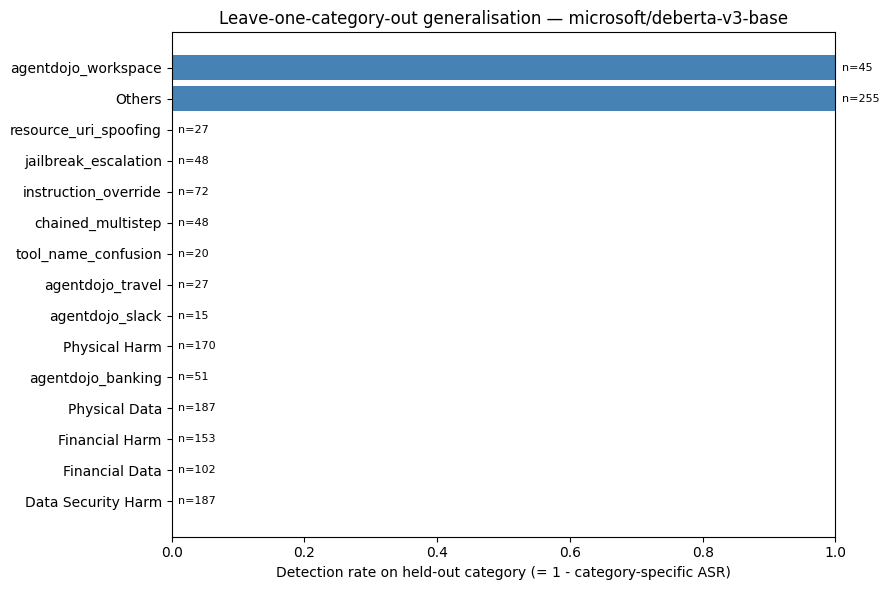


Categories with the fewest test examples have the noisiest estimates — treat those detection rates as rougher signals, not precise numbers, and say so if you report them (your proposal already plans bootstrap 95% CIs for the full generalisation study — this run is a first pass).


In [ ]:
fig, ax = plt.subplots(figsize=(9, max(4, len(loo_df) * 0.4)))
ax.barh(loo_df["held_out_category"], loo_df["detection_rate"], color="steelblue")
ax.set_xlabel("Detection rate on held-out category (= 1 - category-specific ASR)")
ax.set_title(f"Leave-one-category-out generalisation — {MODEL_NAME}")
ax.set_xlim(0, 1)
for i, (rate, n) in enumerate(zip(loo_df["detection_rate"], loo_df["n_attack_test"])):
    ax.text(rate + 0.01, i, f"n={n}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("/content/leave_one_out_plot.png", dpi=150, bbox_inches="tight")
plt.show()



## 17. Save everything and download

Downloads the main checkpoint, both plots, and the leave-one-out results
CSV in one zip.


In [ ]:
trainer.save_model("/content/guard-checkpoint/final")
tokenizer.save_pretrained("/content/guard-checkpoint/final")

import shutil
os.makedirs("/content/deliverables", exist_ok=True)
shutil.copy("/content/confusion_matrix.png", "/content/deliverables/")
shutil.copy("/content/roc_curve.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_plot.png", "/content/deliverables/")
shutil.copy("/content/leave_one_out_results.csv", "/content/deliverables/")
shutil.copytree("/content/guard-checkpoint/final", "/content/deliverables/guard-checkpoint-final")

shutil.make_archive("/content/mcp-ipi-guard-training-results", "zip", "/content/deliverables")

from google.colab import files
files.download("/content/mcp-ipi-guard-training-results.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Optional: push the checkpoint to Hugging Face Hub

For connecting to the FastAPI backend's `GUARD_MODEL_PATH` without manual
file copying.


In [ ]:
# from huggingface_hub import login
# login()
#
# HUB_REPO_ID = "your-username/mcp-ipi-guard-guard-classifier"
# trainer.model.push_to_hub(HUB_REPO_ID)
# tokenizer.push_to_hub(HUB_REPO_ID)
# print(f"Set GUARD_MODEL_PATH={HUB_REPO_ID} in the FastAPI backend's .env to use it.")
